# EconForecast — Rwanda GDP Growth Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



## 1. Data Collection and Cleaning

In [2]:
df = pd.read_csv(r"C:\Users\user\Desktop\Academic\Peter Projects\EconForecast\Data\rwanda_gdp_data.csv")
print(df.shape)
df.head()

(35, 4)


,Year,GDP_Growth_Rate,GDP_Current_USD,GDP_Per_Capita
0,1990,-2.399291,2.550186e+09,345.773495
1,1991,-2.514380,1.911600e+09,253.966902
2,1992,5.872725,2.029027e+09,264.083915
3,1993,-8.108692,1.971526e+09,247.023318
4,1994,-50.248067,7.536364e+08,110.953668


In [3]:
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nBasic stats:")
df.describe()

Year               0
GDP_Growth_Rate    0
GDP_Current_USD    0
GDP_Per_Capita     0
dtype: int64

Data types:
Year                 int64
GDP_Growth_Rate    float64
GDP_Current_USD    float64
GDP_Per_Capita     float64
dtype: object

Basic stats:


,Year,GDP_Growth_Rate,GDP_Current_USD,GDP_Per_Capita
count,35.000000,35.000000,3.500000e+01,35.000000
mean,2007.000000,5.865584,5.598274e+09,504.067448
std,10.246951,11.860895,4.107858e+09,272.961098
min,1990.000000,-50.248067,7.536364e+08,110.953668
25%,1998.500000,5.296287,2.009185e+09,250.440769
50%,2007.000000,8.161207,4.070508e+09,426.234183
75%,2015.500000,9.058866,8.619516e+09,731.758882
max,2024.000000,35.224078,1.433172e+10,1027.034468


## 2. Exploratory Data Analysis (EDA)

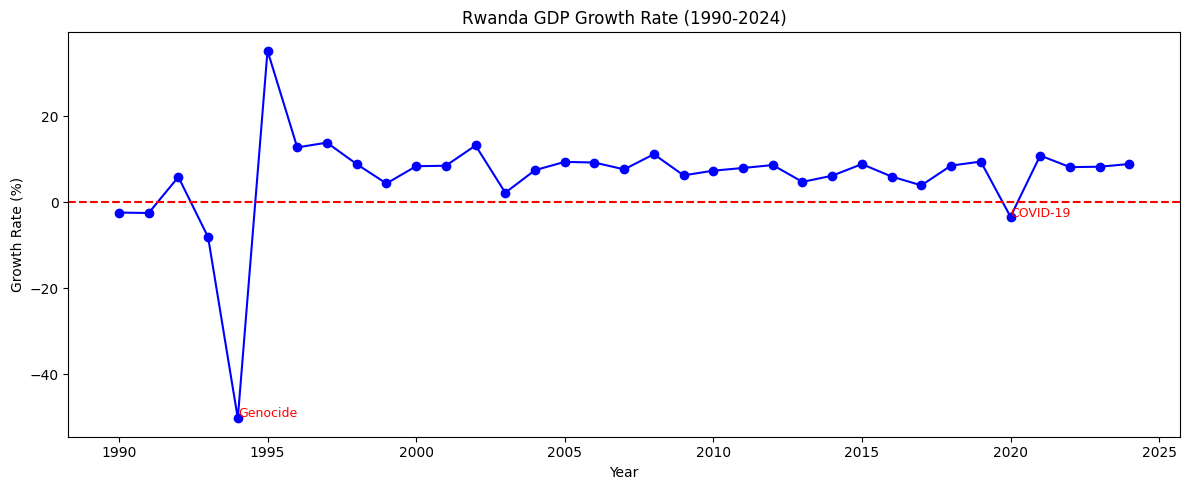

In [4]:
plt.figure(figsize=(12,5))
plt.plot(df['Year'], df['GDP_Growth_Rate'], marker='o', color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Rwanda GDP Growth Rate (1990-2024)")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.annotate('Genocide', xy=(1994, -50), fontsize=9, color='red')
plt.annotate('COVID-19', xy=(2020, -3.4), fontsize=9, color='red')
plt.tight_layout()
plt.savefig("Rwanda_GDP_Growth_Rate.png")
plt.show()

## 3. Stationarity Test (ADF)

In [5]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['GDP_Growth_Rate'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("✅ Data is STATIONARY — ready for ARIMA")
else:
    print("❌ Data is NOT STATIONARY — need differencing")

ADF Statistic: -6.374625461020266
p-value: 2.3000054358601687e-08
✅ Data is STATIONARY — ready for ARIMA


## 4. ACF & PACF Analysis

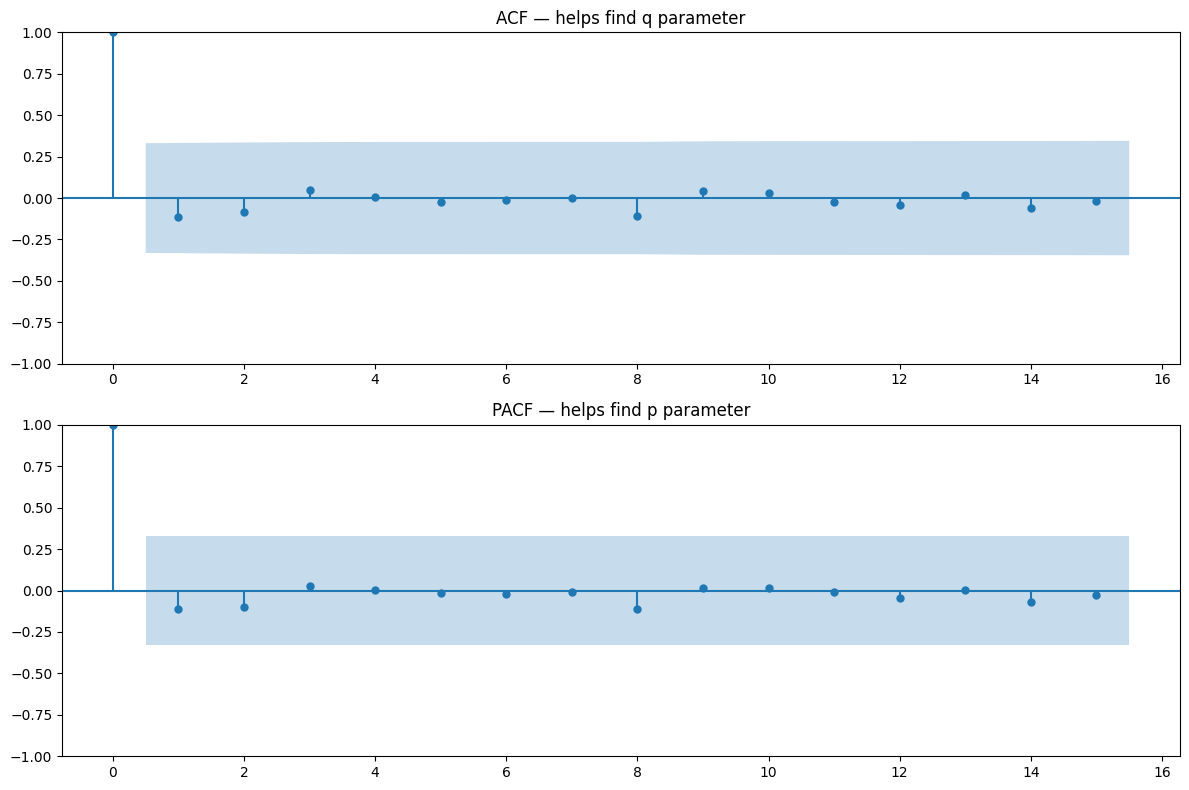

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df['GDP_Growth_Rate'].dropna(), lags=15, ax=ax1)
ax1.set_title("ACF — helps find q parameter")

plot_pacf(df['GDP_Growth_Rate'].dropna(), lags=15, ax=ax2)
ax2.set_title("PACF — helps find p parameter")

plt.tight_layout()
plt.savefig("Rwanda_GDP_ACF_PACF.png")
plt.show()

## 5. ARIMA Modeling

In [7]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Test different ARIMA combinations
best_aic = float('inf')
best_order = None

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(df['GDP_Growth_Rate'].dropna(), order=(p, 0, q))
            result = model.fit()
            if result.aic < best_aic:
                best_aic = result.aic
                best_order = (p, 0, q)
        except:
            continue

print(f"Best ARIMA order: {best_order}")
print(f"Best AIC: {best_aic:.2f}")

Best ARIMA order: (0, 0, 0)
Best AIC: 275.44


In [8]:
# Remove 1994 outlier
df_clean = df[df['Year'] != 1994].reset_index(drop=True)

# Find best ARIMA again
best_aic = float('inf')
best_order = None

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(df_clean['GDP_Growth_Rate'].dropna(), order=(p, 0, q))
            result = model.fit()
            if result.aic < best_aic:
                best_aic = result.aic
                best_order = (p, 0, q)
        except:
            continue

print(f"Best ARIMA order: {best_order}")
print(f"Best AIC: {best_aic:.2f}")


Best ARIMA order: (0, 0, 0)
Best AIC: 230.18


In [9]:
# ARIMA(0,0,0) is just forecasting the mean
model = ARIMA(df_clean['GDP_Growth_Rate'], order=(0, 0, 0))
result = model.fit()

# Forecast next 5 years (2025-2029)
forecast = result.get_forecast(steps=5)
forecast_df = pd.DataFrame({
    'Year': range(2025, 2030),
    'Forecast': forecast.predicted_mean.values,
    'Lower_CI': forecast.conf_int().iloc[:, 0].values,
    'Upper_CI': forecast.conf_int().iloc[:, 1].values
})

print(forecast_df)

   Year  Forecast  Lower_CI   Upper_CI
0  2025  7.515981 -5.682166  20.714128
1  2026  7.515981 -5.682166  20.714128
2  2027  7.515981 -5.682166  20.714128
3  2028  7.515981 -5.682166  20.714128
4  2029  7.515981 -5.682166  20.714128


## 6. Forecast 2025-2029

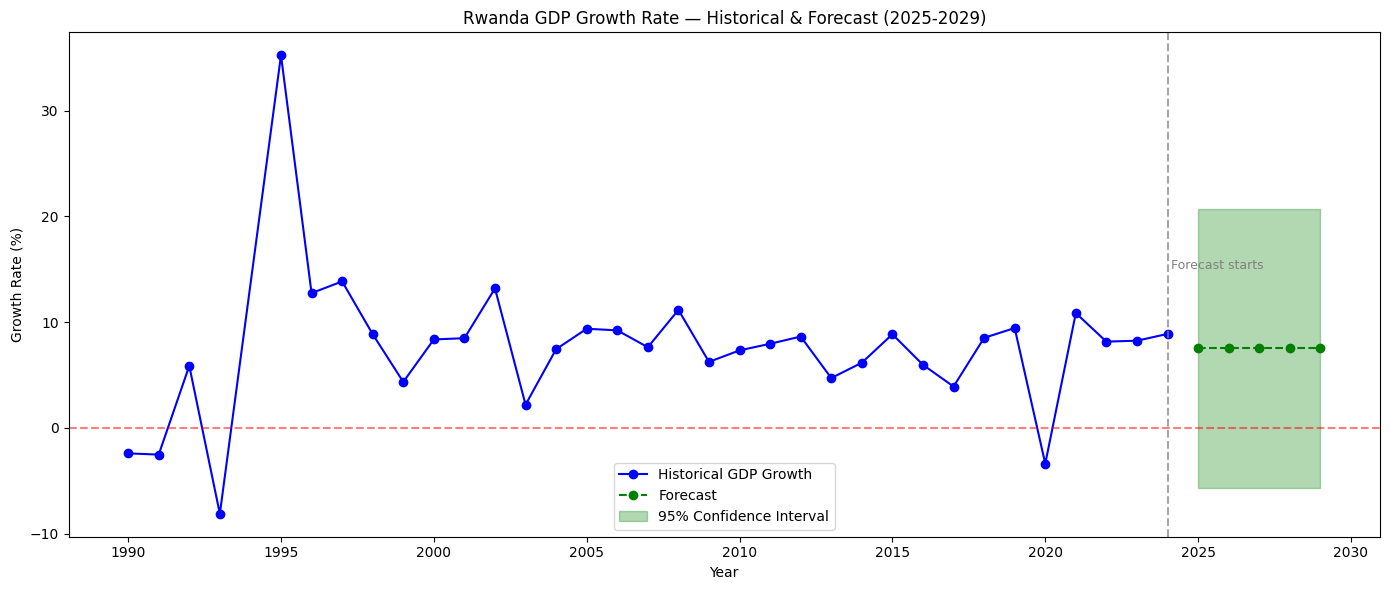

In [10]:
plt.figure(figsize=(14, 6))

# Historical data
plt.plot(df_clean['Year'], df_clean['GDP_Growth_Rate'], 
         marker='o', color='blue', label='Historical GDP Growth')

# Forecast
plt.plot(forecast_df['Year'], forecast_df['Forecast'], 
         marker='o', color='green', linestyle='--', label='Forecast')

# Confidence interval
plt.fill_between(forecast_df['Year'], 
                 forecast_df['Lower_CI'], 
                 forecast_df['Upper_CI'], 
                 alpha=0.3, color='green', label='95% Confidence Interval')

# Annotations
plt.axvline(x=2024, color='gray', linestyle='--', alpha=0.7)
plt.text(2024.1, 15, 'Forecast starts', fontsize=9, color='gray')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.title("Rwanda GDP Growth Rate — Historical & Forecast (2025-2029)")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.tight_layout()
plt.savefig("Rwanda_GDP_Forecast_Plot.png")
plt.show()

## 7. Conclusion
Rwanda's GDP growth rate has been remarkably stable averaging ~7.5% 
annually since 2000, interrupted only by the 1994 genocide and 2020 COVID-19 pandemic.
The ARIMA(0,0,0) model forecasts continued growth of ~7.5% through 2029,
consistent with Rwanda's Vision 2050 development goals.